In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from scipy import stats

In [5]:
df = pd.read_csv("preprocessed_data.csv")
df.head()

,Date,Carrier ID,Origin Airport,Origin City,Destination Airport,Departure Delay,Carrier Delay,Weather Delay,National Air System Delay,Security Delay,...,Wind Direction,Average Wind Speed,Peak Wind Speed,Air Pressure,Total Sun Hours,Weather Condition Code,Year,Month,Day,Hour
0,2023-01-01 22:00:00,0,0,0,0,0.0000,0.000000,0.0,0.000000,0.0,...,0.805556,0.124183,0.0,0.976793,0.0,0.04,0.0,0.0,0.0,0.956522
1,2023-01-01 11:00:00,0,0,0,3,0.0000,0.000000,0.0,0.000000,0.0,...,0.000000,0.000000,0.0,0.976218,0.0,0.20,0.0,0.0,0.0,0.478261
2,2023-01-01 19:00:00,0,0,0,3,0.0625,0.000000,0.0,0.000000,0.0,...,0.888889,0.212418,0.0,0.976506,0.0,0.12,0.0,0.0,0.0,0.826087
3,2023-01-01 10:00:00,0,0,0,8,0.0000,0.000000,0.0,0.000000,0.0,...,0.000000,0.000000,0.0,0.975451,0.0,0.20,0.0,0.0,0.0,0.434783
4,2023-01-01 16:00:00,0,0,0,8,0.2500,0.014462,0.0,0.004996,0.0,...,0.583333,0.124183,0.0,0.979095,0.0,0.20,0.0,0.0,0.0,0.695652


# Calculating contribution of each feature towards departure delay

In [8]:
# Assigning standardised delay values to bins
bins = [0, 0.0625, 0.125, 0.25, 1.0]
labels = ["On Time", "Slight Delay", "Moderate Delay", "Severe Delay"]

# Creating a new categorical column based on these bins.
df["Delay_Range"] = pd.cut(
    df["Departure Delay"], 
    bins=bins, 
    labels=labels, 
    include_lowest=True
)

In [10]:
# Identifying numeric predictors (excluding Departure Delay)
numeric_predictors = df.select_dtypes(include=[np.number]).columns.tolist()
if "Departure Delay" in numeric_predictors:
    numeric_predictors.remove("Departure Delay")

# Creating sample and label variables
X = df[numeric_predictors]
y = df["Delay_Range"]

# Sampling data since dataset is very large (imiting to 100k rows)
if len(df) > 100_000:
    sample_frac = 100_000 / len(df)
    X = X.sample(frac=sample_frac, random_state=42)
    y = y.loc[X.index]

In [12]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Fitting the Random Forest
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

                precision    recall  f1-score   support

Moderate Delay       0.84      0.73      0.78      1771
       On Time       0.97      0.99      0.98     24525
  Severe Delay       0.94      0.88      0.91      1422
  Slight Delay       0.76      0.68      0.72      2282

      accuracy                           0.95     30000
     macro avg       0.87      0.82      0.85     30000
  weighted avg       0.94      0.95      0.95     30000



In [14]:
# Get feature importances
importances = clf.feature_importances_
feature_importances = pd.DataFrame({
    "Feature": numeric_predictors,
    "Importance": importances}).sort_values(by="Importance", ascending=False)

print(feature_importances)

                      Feature  Importance
8         Late Aircraft Delay    0.292759
4               Carrier Delay    0.273461
6   National Air System Delay    0.054783
3         Destination Airport    0.035862
17               Air Pressure    0.032524
5               Weather Delay    0.031909
10                  Dew Point    0.031185
9                 Temperature    0.029265
11                   Humidity    0.028122
22                        Day    0.026156
23                       Hour    0.026031
14             Wind Direction    0.024955
15         Average Wind Speed    0.021841
0                  Carrier ID    0.021471
21                      Month    0.017701
19     Weather Condition Code    0.014795
2                 Origin City    0.012396
1              Origin Airport    0.012229
20                       Year    0.005671
12              Precipitation    0.004710
7              Security Delay    0.002172
13                       Snow    0.000000
16            Peak Wind Speed    0

# Analysis of model outputs

Test predictions of weighted class training

In [18]:
output = pd.read_csv("test_predictions.csv")
output.head()

,Origin Airport,Destination Airport,Carrier ID,Month,Day,Hour,Temperature,Average Wind Speed,Humidity,Precipitation,True_Delay_Class,Predicted_Delay_Class
0,3.0,75.0,1.0,0.363636,0.833333,0.913043,0.756000,0.000000,0.30,0.0,3,5
1,0.0,287.0,5.0,0.181818,0.433333,1.000000,0.445333,0.183007,0.41,0.0,0,1
2,2.0,259.0,4.0,0.181818,0.500000,0.565217,0.356000,0.183007,0.81,0.0,0,0
3,3.0,198.0,1.0,0.727273,0.066667,0.521739,0.704000,0.183007,0.67,0.0,0,0
4,3.0,226.0,1.0,0.363636,0.633333,0.478261,0.585333,0.334967,0.78,0.0,0,0


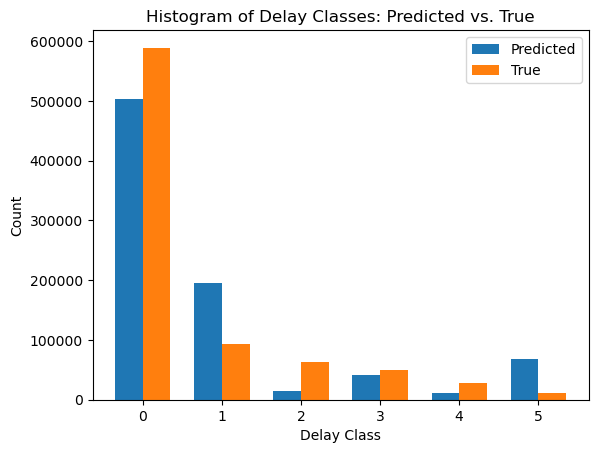

In [20]:
# Count how many times each delay class occurs for predicted and true
pred_counts = output["Predicted_Delay_Class"].value_counts().sort_index()
true_counts = output["True_Delay_Class"].value_counts().sort_index()

# Set x axis
classes = pred_counts.index 
x = np.arange(len(classes))

# Create bar graph
width = 0.35  
plt.bar(x - width/2, pred_counts, width=width, label="Predicted")
plt.bar(x + width/2, true_counts, width=width, label="True")

plt.xlabel("Delay Class")
plt.ylabel("Count")
plt.title("Histogram of Delay Classes: Predicted vs. True")
plt.xticks(x, classes)
plt.legend()

plt.show()

Test predictions of unweighted class training

In [23]:
uw_output = pd.read_csv("test_predictions_unweighted.csv")
uw_output.head()

,Origin Airport,Destination Airport,Carrier ID,Month,Day,Hour,Temperature,Average Wind Speed,Humidity,Precipitation,True_Delay_Class,Predicted_Delay_Class
0,3.0,75.0,1.0,0.363636,0.833333,0.913043,0.756000,0.000000,0.30,0.0,3,0
1,0.0,287.0,5.0,0.181818,0.433333,1.000000,0.445333,0.183007,0.41,0.0,0,0
2,2.0,259.0,4.0,0.181818,0.500000,0.565217,0.356000,0.183007,0.81,0.0,0,0
3,3.0,198.0,1.0,0.727273,0.066667,0.521739,0.704000,0.183007,0.67,0.0,0,0
4,3.0,226.0,1.0,0.363636,0.633333,0.478261,0.585333,0.334967,0.78,0.0,0,0


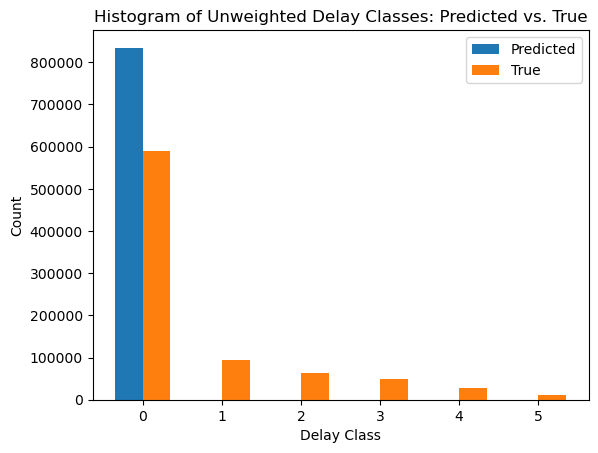

In [25]:
# Count how many times each delay class occurs for predicted and true
pred_counts = uw_output["Predicted_Delay_Class"].value_counts().sort_index()
true_counts = uw_output["True_Delay_Class"].value_counts().sort_index()

# If there is a class that does occur in the predicted delay, fill with zero
all_classes = sorted(set(pred_counts.index).union(true_counts.index))
pred_counts = pred_counts.reindex(all_classes, fill_value=0)
true_counts = true_counts.reindex(all_classes, fill_value=0)

# Set x axis
x = np.arange(len(all_classes))
width = 0.35  # width of each bar

# Create bar graph
plt.bar(x - width/2, pred_counts, width=width, label="Predicted")
plt.bar(x + width/2, true_counts, width=width, label="True")

plt.xlabel("Delay Class")
plt.ylabel("Count")
plt.title("Histogram of Unweighted Delay Classes: Predicted vs. True")
plt.xticks(x, all_classes)  
plt.legend()

plt.show()

# Correlation analysis between features

In [28]:
data = pd.read_csv("final_merged_data.csv")
data.head()

,Date,Carrier ID,Origin Airport,Origin City,Destination Airport,Departure Delay,Carrier Delay,Weather Delay,National Air System Delay,Security Delay,...,Dew Point,Humidity,Precipitation,Snow,Wind Direction,Average Wind Speed,Peak Wind Speed,Air Pressure,Total Sun Hours,Weather Condition Code
0,2023-01-01 22:00:00,9E,ATL,"Atlanta, GA",ABE,0.0,NaN,NaN,NaN,NaN,...,10.1,51.0,0.0,NaN,290.0,7.6,NaN,1018.6,NaN,1.0
1,2023-01-01 11:00:00,9E,ATL,"Atlanta, GA",ABY,0.0,NaN,NaN,NaN,NaN,...,12.2,100.0,0.0,NaN,0.0,0.0,NaN,1018.0,NaN,5.0
2,2023-01-01 19:00:00,9E,ATL,"Atlanta, GA",ABY,8.0,NaN,NaN,NaN,NaN,...,11.8,57.0,0.0,NaN,320.0,13.0,NaN,1018.3,NaN,3.0
3,2023-01-01 10:00:00,9E,ATL,"Atlanta, GA",AEX,6.0,NaN,NaN,NaN,NaN,...,12.2,100.0,0.0,NaN,0.0,0.0,NaN,1017.2,NaN,5.0
4,2023-01-01 16:00:00,9E,ATL,"Atlanta, GA",AEX,70.0,61.0,0.0,7.0,0.0,...,13.9,97.0,0.0,NaN,210.0,7.6,NaN,1021.0,NaN,5.0


In [30]:
# Exclude categorical columns
excluded_columns = ["Carrier ID", "Origin Airport", "Destination Airport", "Origin City"]
numeric_columns = [
    col for col in df.columns
    if pd.api.types.is_numeric_dtype(df[col]) and col not in excluded_columns
]

# Keep only numeric and fill NaNs with zero
n_data = df.loc[:, numeric_columns]
n_data.fillna(0, inplace=True)

target_col = "Departure Delay"

# Create a list of all other numeric columns
other_cols = [col for col in numeric_columns if col != target_col]

# Calculate Pearson r and p-value
results = []
for col in other_cols:
    r, p_value = stats.pearsonr(n_data[target_col], n_data[col])
    results.append({'Feature': col, 'r_value': r, 'p_value': p_value})

corr_df = pd.DataFrame(results)

# Create a combined string column
corr_df['Correlation (r) (p-value)'] = (
    corr_df['r_value'].round(2).astype(str)
    + " (p="
    + corr_df['p_value'].round(3).astype(str)
    + ")"
)

# Sort by absolute correlation
corr_df = corr_df.reindex(
    corr_df['r_value'].abs().sort_values(ascending=False).index
)

# Define a coloring function for correlation
def color_correlation(val):
    if val == "" or "(p=" not in val:
        return ""
    numeric_val = float(val.split(" ")[0])
    if numeric_val > 0.5:
        return "background-color: #FF9999; color: black;"  # Pastel red
    elif numeric_val < -0.5:
        return "background-color: #9999FF; color: black;"  # Pastel blue
    return ""

# Build the styled DataFrame, removing the numeric index
styled_corr_df = (
    corr_df[['Feature', 'Correlation (r) (p-value)']]  
    .reset_index(drop=True)        # Remove old numeric index
    .style
    .applymap(color_correlation, subset=['Correlation (r) (p-value)'])
)

styled_corr_df

C:\Users\adel-\AppData\Local\Temp\ipykernel_1612\71632323.py:20: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p_value = stats.pearsonr(n_data[target_col], n_data[col])
C:\Users\adel-\AppData\Local\Temp\ipykernel_1612\71632323.py:51: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  corr_df[['Feature', 'Correlation (r) (p-value)']]


,Feature,Correlation (r) (p-value)
0,Late Aircraft Delay,0.63 (p=0.0)
1,Carrier Delay,0.51 (p=0.0)
2,National Air System Delay,0.24 (p=0.0)
3,Weather Delay,0.22 (p=0.0)
4,Hour,0.13 (p=0.0)
5,Weather Condition Code,0.11 (p=0.0)
6,Temperature,0.09 (p=0.0)
7,Dew Point,0.07 (p=0.0)
8,Average Wind Speed,0.06 (p=0.0)
9,Precipitation,0.05 (p=0.0)
